# TD n°1
Générons un dataset synthétique en 2D pour nous entraîner

(1200, 2)


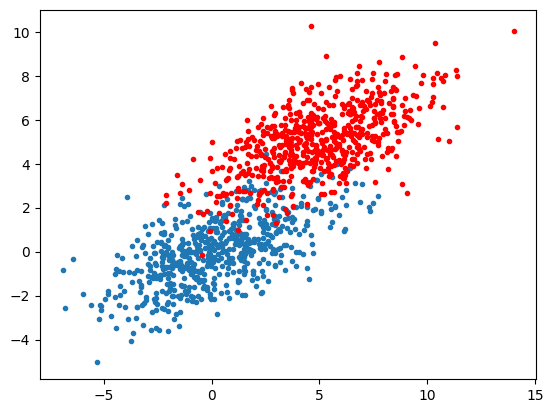

(array([[ 0.48496569,  0.76032263],
        [-2.17355789,  0.30858159],
        [-2.22606912, -2.59044805],
        ...,
        [ 3.20443899,  4.18056884],
        [ 8.38941384,  7.50634404],
        [ 4.58833305,  6.32019756]]),
 array([-1., -1., -1., ...,  1.,  1.,  1.]))

In [4]:
%matplotlib inline

#On commence par importer des modules basique Python
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import matplotlib as mpl

def generateData(seed) :
    n, dim = 600, 2
    np.random.seed(seed)
    C = np.array([[2.67, 0.7], [0.7, 1.45]])
    X = np.r_[np.dot(np.random.randn(n, dim), C) , np.dot(np.random.randn(n, dim), C) + np.array([5, 5])]

    #C = np.array([[1.5, 0.3], [0.3, 0.5]])
    #X = np.r_[ - np.abs( np.dot(np.random.randn(n, dim), C)) + np.array([5, -0.1]) , np.abs(np.dot(np.random.randn(n, dim), C))]

    y = np.hstack((-1*np.ones(n), np.ones(n)))

    #On affiche le dataset
    print(X.shape)
    plt.figure()
    plt.plot(X[:n,0],X[:n,1],'.')
    plt.plot(X[n+1:2*n,0],X[n+1:2*n,1],'.r')
    plt.show()

    return X, y

generateData(4)

## Questions
* jouer avec la seed de np.random pour observer la variabilité du dataset
* séparer les données en ensemble de train et de test (80% pour le train, 20% pour le test)
* On créera des variables X_train et y_train / X_test et y_test

(1200, 2)


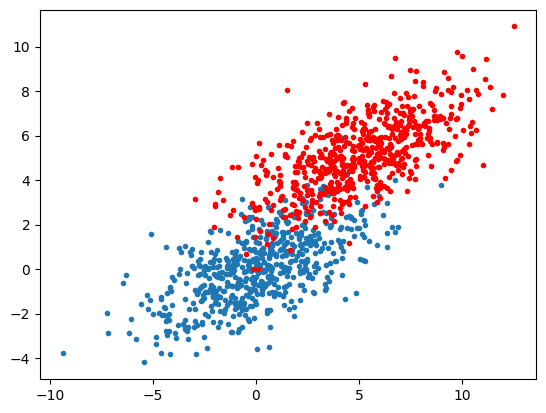

La taille du jeu de données TOTAL est : (1200, 2)
La taille du jeu de données TRAIN est : (960, 2)
La taille du jeu de données TEST est : (240, 2)


In [5]:
#CODE MANQUANT

X , y = generateData(42)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('La taille du jeu de données TOTAL est : ' + str(X.shape))
print('La taille du jeu de données TRAIN est : ' + str(X_train.shape))
print('La taille du jeu de données TEST est : ' + str(X_test.shape))


## Questions
* **En utilisant sklearn**, appliquer les méthodes de classification vues en cours (régression linéaire / rigde + FLD/LDA)
* **En utilisant sklearn**, tracer la courbe ROC et calculer les taux d'erreurs sur les données de test

taux d'erreurs : 0.050000000000000044


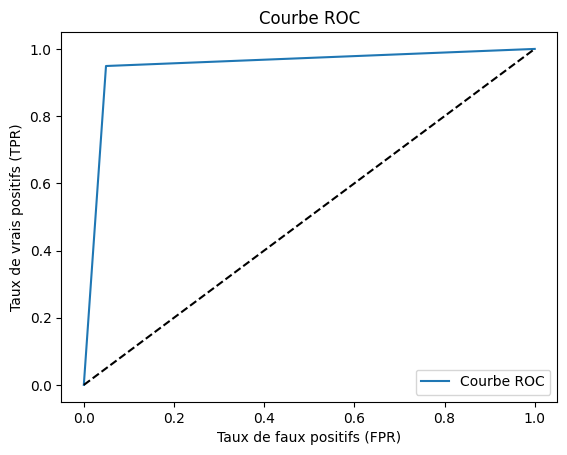

In [8]:
#CODE MANQUANT
from sklearn.metrics import accuracy_score, roc_curve
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_test = lda.predict(X_test)
taux_erreurs = 1 - accuracy_score(y_test, y_pred_test)
print("taux d'erreurs :", taux_erreurs)

fpr, tpr, seuils = roc_curve(y_test, y_pred_test)
plt.plot(fpr, tpr, label='Courbe ROC')
plt.plot([0, 1], [0, 1], '--k')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

## Questions
* A présent, on va commencer à faire de la classification en s'appuyant sur le module sklearn et l'algorithme de $k$-ppv.
* Comme précédemment, calculer l'erreur de test.
* Jouer encore sur le seed et observer l'impact sur l'erreur de test.


taux d'erreurs : 0.07499999999999996


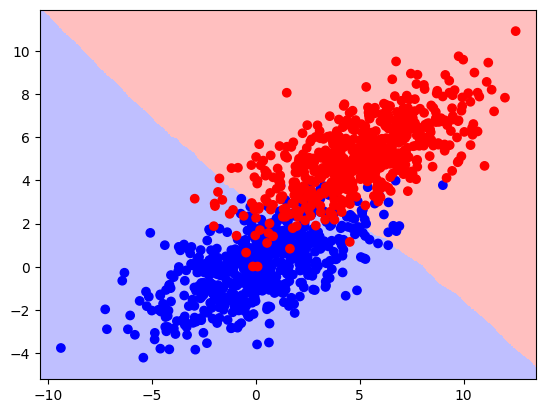

In [12]:
from sklearn import neighbors

#Nombre de voisins
k = 100

clf = neighbors.KNeighborsClassifier(k)
clf.fit(X_train, y_train)

y_pred_test = clf.predict(X_test)
taux_erreurs = 1 - accuracy_score(y_test, y_pred_test)
print("taux d'erreurs :", taux_erreurs)

#Instructions pour afficher la frontière de décision
h = .02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.bwr, alpha=0.25)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()

* **Pour un Classifieur linéaire**, tester avec différents paramètres de régularisation et observer les résultats (en terme de proba d'erreur et de frontière de décision)
* **Pour le classifieur kNN** Tester l'algorithme avec $k=1$, $k=15$ et $k=100$, quel impact sur les résultats ?


7.499999999999996
[-0.00798238  0.16885461]


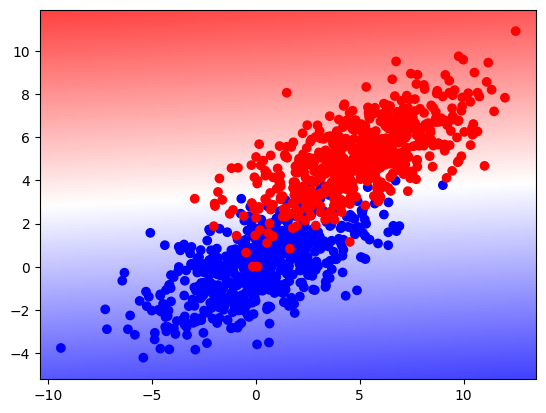

57.08333333333333


In [20]:
n_test = y_test.shape[0]
err_test = 1 - np.sum(clf.predict(X_test)==y_test).astype(float)/n_test
print(err_test *100)

#paramètre l de régularisation
l=100
C = np.dot( np.dot(  np.linalg.inv( np.dot( X_train.T , X_train) + l*np.identity(2) ) , X_train.T ) , y_train)
print(C)
C=C.T

h = .02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Xg= xx.reshape( xx.shape[0]*xx.shape[1] )
Yg= yy.reshape( yy.shape[0]*yy.shape[1] )
Z = np.array([Xg , Yg])

Zlabel = np.dot(C.T, Z) #clf.predict(np.c_[xx.ravel(), yy.ravel()])
Zlabel = Zlabel.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Zlabel, cmap=plt.cm.bwr, alpha=0.75)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()

y_test_regre = np.dot(C.T, X_test.T) > 0.5
y_test_regre= y_test_regre.astype(int)
err_test_regre = (y_test_regre != y_test).astype(float)
#print y_test_estime~
#print y_test
print(np.sum( err_test_regre ) / err_test_regre.shape[0] * 100)




## Questions
* Centrer et Réduire les données et refaire les expériences précédentes


[[1.00000000e+00 7.14839178e-16]
 [7.14839178e-16 1.00000000e+00]] [[ 1.00000000e+00 -7.14839178e-16]
 [-7.14839178e-16  1.00000000e+00]]
(1200, 2)


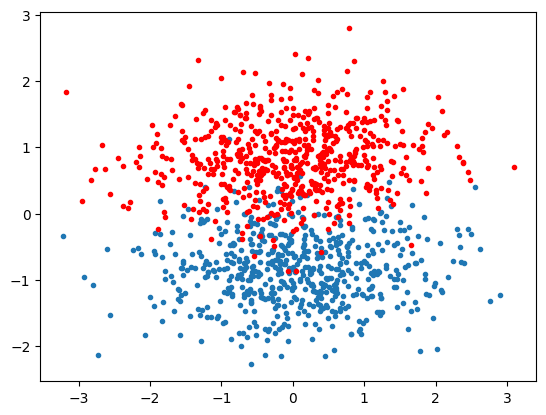

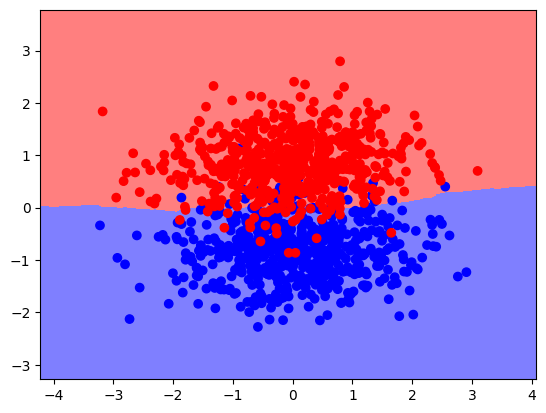

0.0456431535269709


In [22]:
#Centrage
X[:,0] -= np.mean(X[:,0])
X[:,1] -= np.mean(X[:,1])

#Réduction
#X[:,0] /= np.std(X[:,0])
#X[:,1] /= np.std(X[:,1])

#Blanchiment
C=np.cov(X.T)
print(C, np.linalg.inv(C))
W=np.linalg.cholesky(np.linalg.inv(C))
X=np.dot(W.T,X.T).T

# ou tout simplement StandartScaler

#On affiche le dataset
print(X.shape)
n = 600
plt.figure()
plt.plot(X[:n,0],X[:n,1],'.')
plt.plot(X[n+1:2*n,0],X[n+1:2*n,1],'.r')
plt.show()

n_lim = n*0.8
ind_train = np.hstack((np.arange(1,n_lim),np.arange(n,n+n_lim))).astype(int)
X_train = X[ind_train,:]
y_train = y[ind_train]

ind_test = np.setdiff1d(np.arange(2*n),ind_train)
X_test = X[ind_test,:]
y_test = y[ind_test]

#Nombre de voisins
k = 100
clf = neighbors.KNeighborsClassifier(k)
clf.fit(X_train, y_train)

#Instructions pour afficher la frontière de décision
h = .02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.bwr, alpha=0.5)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()

n_test = y_test.shape[0]
err_test = 1 - np.sum(clf.predict(X_test)==y_test).astype(float)/n_test
print(err_test)